In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf as pacf_vals_fn
import seaborn as sns
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectFromModel
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [2]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/INTERNACOES_DOENCA_RESP_RJ.csv"
url_qualiar     = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/DataRio/QUALIAR_RIO_DE_JANEIRO_TRATADO.csv"

df_internacoes = pd.read_csv(url_internacoes, encoding="utf-8")
df_qualiar     = pd.read_csv(url_qualiar,     encoding="utf-8")

df_unificado = (
    pd.merge(df_qualiar, df_internacoes, on="data_dia", how="inner")
      .sort_values("data_dia")
      .reset_index(drop=True)
)

In [3]:
df_unificado['num_internacoes'].mean()

np.float64(297.4660909856782)

In [16]:
import pandas as pd
import numpy as np

def build_feature_dataframe(df_unificado: pd.DataFrame) -> pd.DataFrame:
    """
    Cria um dataframe de modelagem com:
      - alvo: internacoes_d1 (D+1)
      - lags de num_internacoes de 0 a 6
      - médias móveis de num_internacoes nas janelas 7, 14 e 21 (causais)
      - ano_mes_idx = (ano - ano_min) * 12 + mes
      - idx_sazonal_mes_exp: média expandida por mês-do-ano do target_col diário (num_internacoes/internacoes), com shift(1)
      - features ambientais (rolling mean) conforme a tabela (variável, janela, shift)

    Observações de segurança (anti-leak):
      * O alvo é D+1; todas as features são calculadas no máximo até o dia t.
      * Não usamos 'internacoes_d1' para gerar features.
      * Lags e rollings só usam dados históricos (shift >= 0) e rolling inclui a linha corrente (t), o que é seguro para prever t+1.
    """
    # Cópia e ordenação temporal
    df = df_unificado.copy()
    if "data_dia" not in df.columns:
        raise ValueError("Coluna 'data_dia' é obrigatória.")
    df["data_dia"] = pd.to_datetime(df["data_dia"])
    df = df.sort_values("data_dia").reset_index(drop=True)

    # Alvo
    if "internacoes_d1" not in df.columns:
        raise ValueError("Coluna 'internacoes_d1' não encontrada.")
    df["target"] = pd.to_numeric(df["internacoes_d1"], errors="coerce")

    # Garantir ano/mes para o índice composto
    if "ano" not in df.columns:
        df["ano"] = df["data_dia"].dt.year
    if "mes" not in df.columns:
        df["mes"] = df["data_dia"].dt.month

    # ano_mes_idx
    ano_min = int(df["ano"].min())
    df["ano_mes_idx"] = (df["ano"] - ano_min) * 12 + df["mes"]

    # idx_sazonal_mes_exp (média expandida por mês-do-ano do número diário de internações)
    target_col = next((c for c in ["num_internacoes", "internacoes"] if c in df.columns), None)
    if target_col is not None:
        # média expandida por mês (1..12), usando APENAS valores anteriores ao dia atual
        idx_saz = (
            df.groupby(df["data_dia"].dt.month)[target_col]
              .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
              .reset_index(level=0, drop=True)
        )
        df["idx_sazonal_mes_exp"] = idx_saz
    else:
        df["idx_sazonal_mes_exp"] = np.nan  # não deveria acontecer com sua base

    # Lags de num_internacoes (0..6)
    if "num_internacoes" not in df.columns:
        raise ValueError("Coluna 'num_internacoes' não encontrada para criar lags.")
    for k in range(0, 7):
        df[f"num_internacoes_lag{k}"] = df["num_internacoes"].shift(k)

    # Médias móveis causais (janelas 7, 14, 21) de num_internacoes
    # min_periods = janela para respeitar integralmente a janela (evita meia-janela)
    for w in (7, 10, 14, 21, 30):
        df[f"num_internacoes_mm{w}"] = (
            df["num_internacoes"]
              .rolling(window=w, min_periods=w)
              .mean()
        )

    # Tabela de variáveis ambientais com (janela, shift)
    # Interpretação: aplicar shift primeiro (para usar valores até t - shift), depois média móvel causal de 'janela' dias.
    specs = [
        ("o3",   150, 0),
        ("o3",   150, 3),
        ("o3",   150, 5),
        ("no",    60, 0),
        ("so2",  150, 3),
        ("so2",  150, 7),
        ("nox",   60, 0),
        ("no2",   30, 0),
        ("pm10",  30, 0),
    ]

    env_features = []
    for var, janela, sh in specs:
        if var in df.columns:
            serie_shifted = df[var].shift(sh)
            feat_name = f"{var}_rollmean_w{janela}_s{sh}"
            df[feat_name] = serie_shifted.rolling(window=janela, min_periods=janela).mean()
            env_features.append(feat_name)
        # se não existir a coluna, apenas ignora (não cria a feature)

    # Seleção final de colunas (features + alvo)
    feature_cols = (
        [f"num_internacoes_lag{k}" for k in range(0, 7)] +
        [f"num_internacoes_mm{w}" for w in (7, 14, 21)] +
        ["ano_mes_idx", "idx_sazonal_mes_exp"] +
        env_features
    )

    # Construir df_model e remover linhas com NaN (vindos de lags/janelas)
    df_model = df[["data_dia", "target", "ano"] + feature_cols].dropna().reset_index(drop=True)

    # Sanidade: garantir que nenhuma feature usa informações do futuro do ponto de vista de t -> (t+1)
    # (Como todas as operações foram shift/rolling causais com shift >= 0, isso já é assegurado.)
    return df_model

# Exemplo de uso:
df_model = build_feature_dataframe(df_unificado)
df_model.head()


,data_dia,target,ano,num_internacoes_lag0,num_internacoes_lag1,num_internacoes_lag2,num_internacoes_lag3,num_internacoes_lag4,num_internacoes_lag5,num_internacoes_lag6,...,idx_sazonal_mes_exp,o3_rollmean_w150_s0,o3_rollmean_w150_s3,o3_rollmean_w150_s5,no_rollmean_w60_s0,so2_rollmean_w150_s3,so2_rollmean_w150_s7,nox_rollmean_w60_s0,no2_rollmean_w30_s0,pm10_rollmean_w30_s0
0,2012-06-05,936.0,2012,1105,1066.0,559.0,728.0,871.0,754.0,1170.0,...,806.000000,-0.303779,-0.277255,-0.278637,1.136801,0.414301,0.393459,1.034961,1.059812,0.383235
1,2012-06-06,585.0,2012,936,1105.0,1066.0,559.0,728.0,871.0,754.0,...,865.800000,-0.321085,-0.283468,-0.276787,1.174407,0.416940,0.407921,1.061730,1.081700,0.411494
2,2012-06-07,546.0,2012,585,936.0,1105.0,1066.0,559.0,728.0,871.0,...,877.500000,-0.320893,-0.293875,-0.277255,1.179437,0.428246,0.418430,1.058270,1.043066,0.381050
3,2012-06-08,507.0,2012,546,585.0,936.0,1105.0,1066.0,559.0,728.0,...,835.714286,-0.315112,-0.303779,-0.283468,1.200897,0.433921,0.413985,1.064614,1.022174,0.328295
4,2012-06-09,663.0,2012,507,546.0,585.0,936.0,1105.0,1066.0,559.0,...,799.500000,-0.315064,-0.321085,-0.293875,1.187218,0.429439,0.414301,1.052262,0.987779,0.251517


In [17]:

"""
resp_internacoes_modeling.py
---------------------------------
Pipeline robusto para prever internações por doenças respiratórias (D+1)
com suporte a:
- divisão temporal (treino/val/teste) sem vazamento
- baseline de persistência (lag0)
- modelos: Ridge em log1p, HistGradientBoosting (Poisson), Tweedie (log link)
- ensemble (stacking) com meta-aprendiz (Ridge)
- métricas: RMSE, MAE, MAPE, sMAPE (gerais e em dias de salto)
- intervalos preditivos via GradientBoosting quantílico (opcional)
- engenharia leve de features derivadas dos lags (volatilidade, variações)
Autor: você + ChatGPT
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, TweedieRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================
# Utilidades de métrica
# =====================

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def mape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true > 0
    if not np.any(mask):
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / (y_true[mask] + eps))) * 100.0)

def smape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps) / 2.0
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100.0)

def evaluate_all(y_true, y_pred) -> Dict[str, float]:
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "MAPE (%)": mape(y_true, y_pred),
        "sMAPE (%)": smape(y_true, y_pred),
    }

# =====================
# Preparação de dados
# =====================

def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria features adicionais que ajudam a capturar movimentos bruscos (saltos)
    sem causar vazamento (usando apenas lags já presentes).
    - volatilidade7: desvio-padrão dos últimos 7 dias (~lags 0..6)
    - delta_abs_1: |lag0 - lag1|
    - delta_rel_1: (lag0 - lag1)/(lag1+1)
    - delta_abs_7: |lag0 - lag6|
    - delta_rel_7: (lag0 - lag6)/(lag6+1)
    - dows (one-hot): dia da semana do 'data_dia'
    - sazonalidade cíclica simplificada: sin/cos do dia-do-ano
    """
    df = df.copy()
    lag_cols = [c for c in df.columns if c.startswith("num_internacoes_lag")]
    # Garantir que temos pelo menos lag0..lag6
    needed = [f"num_internacoes_lag{k}" for k in range(0,7)]
    if all(c in df.columns for c in needed):
        arr = df[needed].values.astype(float)
        df["volatilidade7"] = np.nanstd(arr, axis=1)
        df["delta_abs_1"] = np.abs(df["num_internacoes_lag0"] - df["num_internacoes_lag1"])
        df["delta_rel_1"] = (df["num_internacoes_lag0"] - df["num_internacoes_lag1"]) / (df["num_internacoes_lag1"] + 1.0)
        df["delta_abs_7"] = np.abs(df["num_internacoes_lag0"] - df["num_internacoes_lag6"])
        df["delta_rel_7"] = (df["num_internacoes_lag0"] - df["num_internacoes_lag6"]) / (df["num_internacoes_lag6"] + 1.0)
    else:
        # Fallback seguro
        df["volatilidade7"] = df.get("num_internacoes_mm7", pd.Series(0, index=df.index))
        df["delta_abs_1"] = 0.0
        df["delta_rel_1"] = 0.0
        df["delta_abs_7"] = 0.0
        df["delta_rel_7"] = 0.0

    # Calendário
    if "data_dia" in df.columns:
        ser = pd.to_datetime(df["data_dia"])
        df["dow"] = ser.dt.dayofweek  # 0=segunda
        df["doy"] = ser.dt.dayofyear
        # codificação cíclica
        df["doy_sin"] = np.sin(2*np.pi * df["doy"] / 366.0)
        df["doy_cos"] = np.cos(2*np.pi * df["doy"] / 366.0)
    else:
        df["dow"] = 0
        df["doy_sin"] = 0.0
        df["doy_cos"] = 0.0
    return df

@dataclass
class Split:
    train_idx: np.ndarray
    valid_idx: np.ndarray
    test_idx: np.ndarray

def time_based_split(dates: pd.Series, valid_days: int = 365, test_days: int = 365) -> Split:
    dates = pd.to_datetime(dates)
    end_date = dates.max()
    test_start = end_date - pd.Timedelta(days=test_days-1)
    valid_start = test_start - pd.Timedelta(days=valid_days)
    train_mask = dates < valid_start
    valid_mask = (dates >= valid_start) & (dates < test_start)
    test_mask  = dates >= test_start
    return Split(np.where(train_mask)[0], np.where(valid_mask)[0], np.where(test_mask)[0])

def build_matrices(df_model: pd.DataFrame, extra_onehot: bool = True) -> Tuple[pd.DataFrame, np.ndarray, List[str], ColumnTransformer]:
    """
    Separa X, y e prepara transformações por tipo de variável para modelos lineares.
    """
    df = add_derived_features(df_model)

    y = df["target"].values.astype(float)
    # Features candidatas: tudo exceto colunas óbvias de não-feature
    exclude = {"target", "internacoes_d1"}
    # vamos manter 'ano' e 'ano_mes_idx' como numéricas
    num_cols = []
    cat_cols = []
    for c in df.columns:
        if c in exclude: continue
        if c == "data_dia": continue
        if df[c].dtype.kind in "biufc":  # numeric
            num_cols.append(c)
        else:
            cat_cols.append(c)

    # Opcionalmente forçar 'dow' como categórica
    if extra_onehot and "dow" in df.columns:
        if "dow" in num_cols:
            num_cols.remove("dow")
        if "dow" not in cat_cols:
            cat_cols.append("dow")

    # Transformadores
    numeric_transformer = Pipeline(steps=[("scaler", StandardScaler(with_mean=True, with_std=True))])
    categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]) if cat_cols else "drop"

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ]
    )

    X = df[num_cols + cat_cols].copy()  # manter DataFrame para referências
    feature_names = num_cols + cat_cols
    return X, y, feature_names, preprocessor

# =====================
# Modelos
# =====================

def fit_ridge_log(X, y, preprocessor: ColumnTransformer, alpha: float = 5.0) -> Pipeline:
    """
    Modelo linear em log1p do alvo. Predição é invertida com expm1 e truncada em 0.
    """
    model = Pipeline(steps=[
        ("prep", preprocessor),
        ("ridge", Ridge(alpha=alpha, random_state=42))
    ])
    # y transformado
    y_log = np.log1p(y)
    model.fit(X, y_log)
    return model

def predict_ridge_log(model: Pipeline, X) -> np.ndarray:
    y_log_pred = model.predict(X)
    y_pred = np.expm1(y_log_pred)
    return np.clip(y_pred, 0.0, None)

def fit_hgb_poisson(X, y) -> HistGradientBoostingRegressor:
    """
    HGB Regressor com perda Poisson: adequado para contagens com variância crescente.
    """
    # HistGBR não aceita preprocessors do sklearn diretamente via ColumnTransformer,
    # então usamos dummies para categóricas mais simples (dow já foi one-hot no preprocessor? Aqui assumimos apenas numéricas).
    # Para simplicidade, usamos apenas colunas numéricas já contínuas (incluindo dummies se você as tiver criado).
    # Se precisar de one-hot, crie antes e passe no X.
    model = HistGradientBoostingRegressor(
        loss="poisson",
        learning_rate=0.05,
        max_depth=None,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=1.0,
        early_stopping=True,
        random_state=42
    )
    y_pos = np.clip(y, 0, None)
    model.fit(X, y_pos)
    return model

def fit_tweedie_loglink(X, y, alpha: float = 0.001, power: float = 1.3) -> Pipeline:
    """
    Tweedie (1<p<2) com link log; robusto para dados de contagem superdispersos.
    """
    num_cols = X.columns.tolist()
    preprocessor = ColumnTransformer([("num", StandardScaler(), num_cols)])
    model = Pipeline(steps=[
        ("prep", preprocessor),
        ("tweedie", TweedieRegressor(power=power, alpha=alpha, link="log", max_iter=1000))
    ])
    y_pos = np.clip(y, 0, None)
    model.fit(X, y_pos)
    return model

def fit_quantile_gbr(X, y, alpha_q: float = 0.9) -> GradientBoostingRegressor:
    return GradientBoostingRegressor(
        loss="quantile",
        alpha=alpha_q,
        learning_rate=0.05,
        n_estimators=400,
        max_depth=3,
        random_state=42
    ).fit(X, y)

# =====================
# Avaliação e Ensemble
# =====================

def select_columns_for_hgb(X: pd.DataFrame) -> pd.DataFrame:
    """
    HGBR precisa de matriz numérica. Vamos converter 'dow' em dummies se existir.
    """
    Xh = X.copy()
    if "dow" in Xh.columns and not np.issubdtype(Xh["dow"].dtype, np.number):
        Xh = pd.get_dummies(Xh, columns=["dow"], drop_first=False)
    elif "dow" in Xh.columns:
        # garantir dummies mesmo se for int
        Xh = pd.get_dummies(Xh, columns=["dow"], drop_first=False)
    return Xh

def evaluate_models(df_model: pd.DataFrame, valid_days: int = 365, test_days: int = 365) -> Dict:
    # Build matrices and split
    X, y, feat_names, preproc = build_matrices(df_model)
    dates = pd.to_datetime(df_model["data_dia"])

    split = time_based_split(dates, valid_days=valid_days, test_days=test_days)
    Xtr, ytr = X.iloc[split.train_idx], y[split.train_idx]
    Xva, yva = X.iloc[split.valid_idx], y[split.valid_idx]
    Xte, yte = X.iloc[split.test_idx], y[split.test_idx]

    # Baseline persistência: usa lag0 na mesma linha para prever D+1
    if "num_internacoes_lag0" not in X.columns:
        raise ValueError("Feature 'num_internacoes_lag0' é necessária para o baseline de persistência.")
    baseline_pred_va = Xva["num_internacoes_lag0"].values.astype(float)
    baseline_pred_te = Xte["num_internacoes_lag0"].values.astype(float)

    # Ridge em log1p
    ridge_log = fit_ridge_log(Xtr, ytr, preproc, alpha=5.0)
    ridge_va = predict_ridge_log(ridge_log, Xva)
    ridge_te = predict_ridge_log(ridge_log, Xte)

    # HGB Poisson (sem pré-processamento, trabalha no X numérico)
    Xtr_hgb = select_columns_for_hgb(Xtr)
    Xva_hgb = select_columns_for_hgb(Xva)
    Xte_hgb = select_columns_for_hgb(Xte)
    hgb = fit_hgb_poisson(Xtr_hgb, ytr)
    hgb_va = np.clip(hgb.predict(Xva_hgb), 0.0, None)
    hgb_te = np.clip(hgb.predict(Xte_hgb), 0.0, None)

    # Tweedie log link
    tweedie = fit_tweedie_loglink(Xtr, ytr, alpha=1e-3, power=1.3)
    tw_va = np.clip(tweedie.predict(Xva), 0.0, None)
    tw_te = np.clip(tweedie.predict(Xte), 0.0, None)

    # Stacking simples (meta Ridge) com as 3 predições + lag0 e volatilidade
    def _stack_feats(Xslice, preds_list):
        cols = [preds_list[0], preds_list[1], preds_list[2]]
        Z = np.vstack(cols).T  # (n, 3)
        extra = []
        if "num_internacoes_lag0" in Xslice.columns:
            extra.append(Xslice["num_internacoes_lag0"].values.astype(float))
        if "volatilidade7" in Xslice.columns:
            extra.append(Xslice["volatilidade7"].values.astype(float))
        if extra:
            Z = np.column_stack([Z] + extra)
        return Z

    Zva = _stack_feats(Xva, [ridge_va, hgb_va, tw_va])
    Zte = _stack_feats(Xte, [ridge_te, hgb_te, tw_te])

    meta = Ridge(alpha=1.0, random_state=42)
    meta.fit(Zva, yva)
    stack_va = np.clip(meta.predict(Zva), 0.0, None)
    stack_te = np.clip(meta.predict(Zte), 0.0, None)

    # Avaliação geral
    results = {
        "baseline_persistencia": {
            "valid": evaluate_all(yva, baseline_pred_va),
            "test": evaluate_all(yte, baseline_pred_te),
        },
        "ridge_log": {
            "valid": evaluate_all(yva, ridge_va),
            "test": evaluate_all(yte, ridge_te),
        },
        "hgb_poisson": {
            "valid": evaluate_all(yva, hgb_va),
            "test": evaluate_all(yte, hgb_te),
        },
        "tweedie_log": {
            "valid": evaluate_all(yva, tw_va),
            "test": evaluate_all(yte, tw_te),
        },
        "stacking_meta_ridge": {
            "valid": evaluate_all(yva, stack_va),
            "test": evaluate_all(yte, stack_te),
        }
    }

    # Métricas focadas em dias de salto (mudança abrupta vs lag0)
    # definimos "salto" se |y_true - lag0| >= max(0.5*y_true, 80)
    def jump_mask(Xslice, yslice):
        if "num_internacoes_lag0" not in Xslice.columns:
            return np.zeros_like(yslice, dtype=bool)
        lag0 = Xslice["num_internacoes_lag0"].values.astype(float)
        return np.abs(yslice - lag0) >= np.maximum(0.5 * np.maximum(yslice, 1.0), 80.0)

    jmask_va = jump_mask(Xva, yva)
    jmask_te = jump_mask(Xte, yte)

    def eval_jumps(y, pred, mask):
        if not np.any(mask):
            return {"RMSE": np.nan, "MAE": np.nan, "MAPE (%)": np.nan, "sMAPE (%)": np.nan, "n": int(mask.sum())}
        m = evaluate_all(y[mask], pred[mask])
        m["n"] = int(mask.sum())
        return m

    results_jumps = {
        "baseline_persistencia": {
            "valid": eval_jumps(yva, baseline_pred_va, jmask_va),
            "test": eval_jumps(yte, baseline_pred_te, jmask_te),
        },
        "ridge_log": {
            "valid": eval_jumps(yva, ridge_va, jmask_va),
            "test": eval_jumps(yte, ridge_te, jmask_te),
        },
        "hgb_poisson": {
            "valid": eval_jumps(yva, hgb_va, jmask_va),
            "test": eval_jumps(yte, hgb_te, jmask_te),
        },
        "tweedie_log": {
            "valid": eval_jumps(yva, tw_va, jmask_va),
            "test": eval_jumps(yte, tw_te, jmask_te),
        },
        "stacking_meta_ridge": {
            "valid": eval_jumps(yva, stack_va, jmask_va),
            "test": eval_jumps(yte, stack_te, jmask_te),
        }
    }

    # Intervalos preditivos (opcionais) no conjunto de teste a partir do melhor modelo (stacking)
    # Ajustamos quantis em (train+valid) e prevemos no teste
    Xtrva = pd.concat([Xtr, Xva], axis=0)
    ytrva  = np.concatenate([ytr, yva], axis=0)
    q10 = fit_quantile_gbr(select_columns_for_hgb(Xtrva), ytrva, alpha_q=0.10)
    q90 = fit_quantile_gbr(select_columns_for_hgb(Xtrva), ytrva, alpha_q=0.90)
    ints = {
        "q10": np.clip(q10.predict(select_columns_for_hgb(Xte)), 0.0, None),
        "q90": np.clip(q90.predict(select_columns_for_hgb(Xte)), 0.0, None),
    }

    # Coletar também as predições finais (teste)
    preds = {
        "dates_test": pd.to_datetime(dates.iloc[split.test_idx]).tolist(),
        "y_test": yte.tolist(),
        "baseline_test": baseline_pred_te.tolist(),
        "ridge_log_test": ridge_te.tolist(),
        "hgb_poisson_test": hgb_te.tolist(),
        "tweedie_log_test": tw_te.tolist(),
        "stack_test": stack_te.tolist(),
        "q10_test": ints["q10"].tolist(),
        "q90_test": ints["q90"].tolist(),
    }

    # Importâncias do HGB (apenas para interpretação)
    try:
        importances = dict(zip(select_columns_for_hgb(Xtr).columns.tolist(),
                               hgb.feature_importances_.tolist()))
    except Exception:
        importances = {}

    out = {
        "metrics_overall": results,
        "metrics_jumps": results_jumps,
        "feature_names": feat_names,
        "hgb_feature_importances": importances,
        "predictions_test": preds,
        "split_sizes": {
            "train": int(len(split.train_idx)),
            "valid": int(len(split.valid_idx)),
            "test": int(len(split.test_idx)),
        }
    }
    return out

# =====================
# Uso
# =====================
"""
Exemplo (no seu notebook/script principal, onde já existe df_model):
------------------------------------------------------------
from resp_internacoes_modeling import evaluate_models

resultados = evaluate_models(df_model, valid_days=365, test_days=365)

# Tabela de métricas (teste)
import pandas as pd
tabela = pd.DataFrame({k: v["test"] for k, v in resultados["metrics_overall"].items()}).T
tabela

# Métricas focadas em dias de salto (teste)
tabela_jumps = pd.DataFrame({k: v["test"] for k, v in resultados["metrics_jumps"].items()}).T
tabela_jumps

# Predições com intervalos (para plot)
preds = resultados["predictions_test"]
df_pred = pd.DataFrame({
    "data_dia": preds["dates_test"],
    "y_true": preds["y_test"],
    "y_pred_stack": preds["stack_test"],
    "q10": preds["q10_test"],
    "q90": preds["q90_test"],
})
"""

resultados = evaluate_models(df_model, valid_days=365, test_days=365)

# Tabela de métricas (teste)
import pandas as pd
tabela = pd.DataFrame({k: v["test"] for k, v in resultados["metrics_overall"].items()}).T
tabela

# Métricas focadas em dias de salto (teste)
tabela_jumps = pd.DataFrame({k: v["test"] for k, v in resultados["metrics_jumps"].items()}).T
tabela_jumps

# Predições com intervalos (para plot)
preds = resultados["predictions_test"]
df_pred = pd.DataFrame({
    "data_dia": preds["dates_test"],
    "y_true": preds["y_test"],
    "y_pred_stack": preds["stack_test"],
    "q10": preds["q10_test"],
    "q90": preds["q90_test"],
})


In [19]:
tabela_jumps

,RMSE,MAE,MAPE (%),sMAPE (%),n
baseline_persistencia,110.614646,110.000000,80.329586,77.490280,5.0
ridge_log,70.090634,67.006591,54.104434,44.137589,5.0
hgb_poisson,58.086454,51.517457,43.795623,34.373210,5.0
tweedie_log,60.053496,54.612905,46.297641,36.326171,5.0
stacking_meta_ridge,74.680824,74.023443,53.557548,50.493376,5.0


In [20]:
# 365 dias p/ validação + 365 p/ teste (ajuste se quiser)
result = evaluate_models(df_model, valid_days=365, test_days=365)

# Tabela de métricas (teste)
tabela = pd.DataFrame({k: v["test"] for k, v in result["metrics_overall"].items()}).T
display(tabela.sort_values("RMSE"))

# Tabela de métricas só em dias de salto (teste)
tabela_jumps = pd.DataFrame({k: v["test"] for k, v in result["metrics_jumps"].items()}).T
display(tabela_jumps.sort_values("RMSE"))

,RMSE,MAE,MAPE (%),sMAPE (%)
baseline_persistencia,28.780983,19.665000,23.812769,22.922388
stacking_meta_ridge,35.648201,30.515148,54.651516,38.159713
ridge_log,69.436625,65.402460,117.149999,63.816566
hgb_poisson,76.661585,72.078458,133.851313,67.957687
tweedie_log,79.933056,77.013708,135.893080,70.610576


,RMSE,MAE,MAPE (%),sMAPE (%),n
hgb_poisson,58.086454,51.517457,43.795623,34.373210,5.0
tweedie_log,60.053496,54.612905,46.297641,36.326171,5.0
ridge_log,70.090634,67.006591,54.104434,44.137589,5.0
stacking_meta_ridge,74.680824,74.023443,53.557548,50.493376,5.0
baseline_persistencia,110.614646,110.000000,80.329586,77.490280,5.0


In [7]:
df_model2 = df_model[df_model["data_dia"] <= "2019-12-31"]

df_model2.tail()

,data_dia,target,ano,num_internacoes_lag0,num_internacoes_lag1,num_internacoes_lag2,num_internacoes_lag3,num_internacoes_lag4,num_internacoes_lag5,num_internacoes_lag6,...,idx_sazonal_mes_exp,o3_rollmean_w150_s0,o3_rollmean_w150_s3,o3_rollmean_w150_s5,no_rollmean_w60_s0,so2_rollmean_w150_s3,so2_rollmean_w150_s7,nox_rollmean_w60_s0,no2_rollmean_w30_s0,pm10_rollmean_w30_s0
2420,2019-12-27,222.0,2019,266,266.0,247.0,167.0,216.0,202.0,296.0,...,289.967078,0.541145,0.529872,0.536156,-0.387064,0.141518,0.168002,-0.674198,-0.560117,-0.247041
2421,2019-12-28,170.0,2019,222,266.0,266.0,247.0,167.0,216.0,202.0,...,289.868852,0.537491,0.529074,0.530046,-0.408659,0.143369,0.164453,-0.707538,-0.590459,-0.273966
2422,2019-12-29,181.0,2019,170,222.0,266.0,266.0,247.0,167.0,216.0,...,289.591837,0.536788,0.531358,0.529872,-0.439894,0.141638,0.153984,-0.756787,-0.627665,-0.329582
2423,2019-12-30,115.0,2019,181,170.0,222.0,266.0,266.0,247.0,167.0,...,289.105691,0.538283,0.541145,0.529074,-0.441048,0.148509,0.152378,-0.779922,-0.664522,-0.417270
2424,2019-12-31,245.0,2019,115,181.0,170.0,222.0,266.0,266.0,247.0,...,288.668016,0.534479,0.537491,0.531358,-0.421048,0.156028,0.141518,-0.757276,-0.684931,-0.488986


In [8]:
def create_sequences(data, target, n_steps):
    X_seq, y_seq = [], []

    # Verificação de consistência
    assert len(data) == len(target), "Dados e alvo têm tamanhos diferentes!"

    for i in range(n_steps, len(data)):
        X_seq.append(data[i - n_steps:i])      # janela de n_steps
        y_seq.append(target[i])                # alvo futuro (no tempo i)

    return np.array(X_seq), np.array(y_seq)

def calcular_metricas(y_true, y_pred):
    return {
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAE': round(mean_absolute_error(y_true, y_pred), 2),
        'MAPE (%)': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2)
    }

In [9]:
def criar_modelo_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

In [10]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import numpy as np

def treinar_lstm_model(df, target, n_steps=30, n_splits=5):
    print(f"Treinando modelo LSTM para {target}")

    features = [col for col in df.columns if col not in ['data_dia', 'classificacao',
        'num_internacoes', 'internacoes_d1', 'internacoes_d7', target]]

    X = df[features].values
    y = df[target].values
    y_log = np.log1p(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_seq, y_seq = create_sequences(X_scaled, y_log, n_steps)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    train_index, test_index = list(tscv.split(X_seq))[-1]

    X_train, X_test = X_seq[train_index], X_seq[test_index]
    y_train, y_test = y_seq[train_index], y_seq[test_index]

    test_idx = np.arange(len(y_seq))[test_index]

    model = criar_modelo_lstm((n_steps, X_train.shape[2]))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=32,
        callbacks=[
            EarlyStopping(patience=15, restore_best_weights=True),
            ReduceLROnPlateau(factor=0.5, patience=5)
        ],
        verbose=1
    )

    return model, history, X_test, y_test, test_idx, y_seq, df

In [11]:
def avaliar_lstm(model, history, X_test, y_test, test_idx, y_seq, df, n_steps=14, max_points=150):
    y_pred = np.expm1(model.predict(X_test).flatten())
    y_true = np.expm1(y_test)
    dates = df.iloc[test_idx + n_steps]['data_dia'].values
    resultados = calcular_metricas(y_true, y_pred)

    print(f"\n Chart 1: Last {max_points} points (sequential index)")
    idx_ini = max(0, len(y_true) - max_points)
    x = np.arange(len(y_true))[idx_ini:]
    y_true_plot = y_true[idx_ini:]
    y_pred_plot = y_pred[idx_ini:]

    plt.figure(figsize=(14, 5))
    plt.plot(x, y_true_plot, label="Actual", marker='o')
    plt.plot(x, y_pred_plot, label="LSTM", linestyle='--', marker='s')
    plt.fill_between(x, y_true_plot, y_pred_plot, color='gray', alpha=0.2)
    plt.title(f"LSTM Predictions vs Actual Values (last {max_points})")
    plt.xlabel("Index")
    plt.ylabel("Hospitalizations")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(" Chart 3: Loss curves")
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Training')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title("LSTM Loss Curves")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("\nLSTM Metrics:")
    for metric, value in resultados.items():
        unit = "%" if "MAPE" in metric else ""
        print(f" - {metric:<10}: {value:.2f}{unit}")

    return resultados


In [14]:
df_model.dropna(inplace=True)

model_lstm, hist_lstm, X_test_lstm, y_test_lstm, test_idx_lstm, y_seq_lstm, df_seq = treinar_lstm_model(df_model, 'target')

Treinando modelo LSTM para target
Epoch 1/100


c:\Users\jhter\OneDrive - cefet-rj.br\qualiar\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 2.7616 - val_loss: 0.5562 - learning_rate: 0.0010
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1288 - val_loss: 0.4203 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1033 - val_loss: 0.4598 - learning_rate: 0.0010
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0988 - val_loss: 0.4284 - learning_rate: 0.0010
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0887 - val_loss: 0.3415 - learning_rate: 0.0010
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0844 - val_loss: 0.3943 - learning_rate: 0.0010
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0825 - val_loss: 0.3381 - learning_rate: 0.0010
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0807 - val_loss: 0.3299 - learning_rate: 0.0010
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0825 - val_loss: 0.3120 - learning_rate: 0.0010
Epoch 10/100
94/94 ━━━

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

 Chart 1: Last 150 points (sequential index)


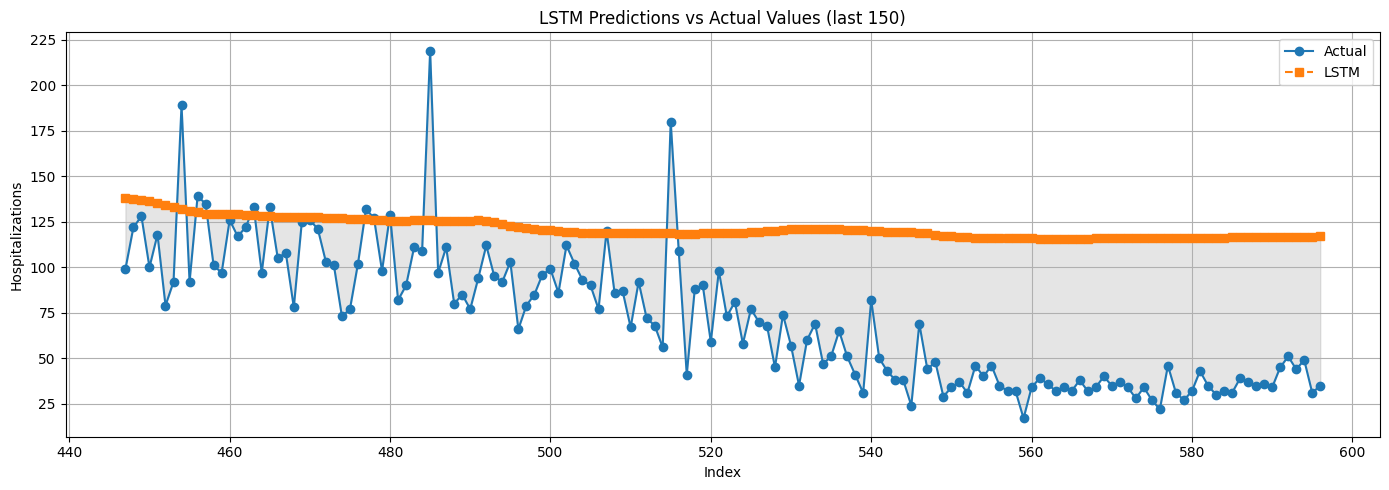

 Chart 3: Loss curves


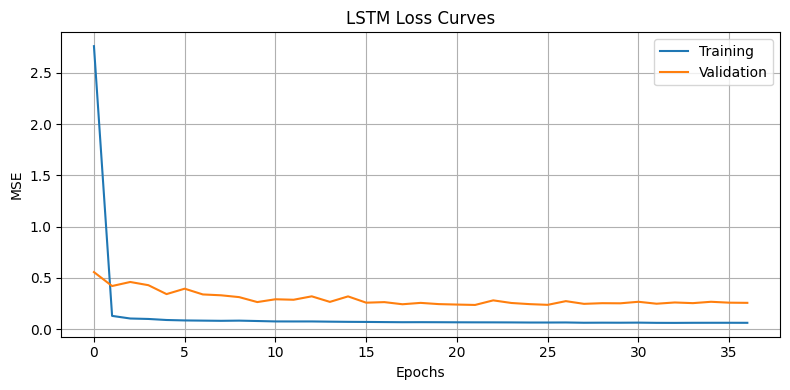


LSTM Metrics:
 - RMSE      : 52.78
 - MAE       : 43.17
 - MAPE (%)  : 50.22%


{'RMSE': np.float64(52.78), 'MAE': 43.17, 'MAPE (%)': 50.22}

In [15]:
avaliar_lstm(model_lstm, hist_lstm, X_test_lstm, y_test_lstm, test_idx_lstm, y_seq_lstm, df_seq)


In [11]:
# =========================
# Imports e utilidades
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers as L, models as M, callbacks as C, regularizers as R

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reprodutibilidade
def set_seed(seed=42):
    import os, random
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)


# =========================
# Sequências e métricas
# =========================
def create_sequences(X, y, n_steps):
    """
    Cria janelas (causais) de tamanho n_steps.
    Para cada amostra, a janela termina em t, e o alvo é y[t].

    Se y == internacoes_d1, então cada par (X_window até t) -> (internacoes_d1[t]) prevê o D+1.
    """
    assert len(X) == len(y), "Dados e alvo têm tamanhos diferentes!"
    X_seq, y_seq, last_idx = [], [], []
    # janela termina em i (inclusive) => [i-n_steps+1 ... i]
    for i in range(n_steps - 1, len(X)):
        X_seq.append(X[i - n_steps + 1:i + 1])
        y_seq.append(y[i])
        last_idx.append(i)  # índice do último dia usado na janela
    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
        np.asarray(last_idx, dtype=np.int64),
    )


def calcular_metricas(y_true, y_pred):
    # MAPE seguro (evita divisão por zero)
    eps = 1e-9
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps)))
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "MAPE (%)": float(mape * 100.0),
    }


# =========================
# Modelo (LSTM melhorado)
# =========================
def criar_modelo_lstm_profundo(
    input_shape,                 # (n_steps, n_features)
    lstm_units=(256, 128, 64, 32),
    dropout=0.2,
    rec_dropout=0.1,
    l2_reg=1e-4,
    lr=1e-3,
    clipnorm=1.0,
    mha_heads=4,
    mha_key_dim=32,
    bidir_first=False,           # True = primeira camada BiLSTM
    loss="huber"                 # "huber" ou "mse"
):
    """
    Stacked LSTM com atalhos residuais + MultiHeadAttention.
    - Residuals (Conv1D 1x1) estabilizam o gradiente em profundidade.
    - Attention melhora a seleção de timesteps relevantes dentro da janela.
    - BiLSTM opcional na 1ª camada (não vaza futuro além da janela).
    """
    inp = L.Input(shape=input_shape, name="inputs")          # (T, F)
    x = L.SpatialDropout1D(0.10, name="spatial_drop")(inp)

    # -------- Bloco 1 --------
    rnn1 = L.LSTM(
        lstm_units[0], return_sequences=True,
        dropout=dropout, recurrent_dropout=rec_dropout,
        kernel_regularizer=R.l2(l2_reg), name="lstm_1"
    )
    if bidir_first:
        x1 = L.Bidirectional(rnn1, name="bilstm_1")(x)
    else:
        x1 = rnn1(x)
    x1 = L.LayerNormalization(name="ln_1")(x1)

    # -------- Bloco 2 (residual com proj 1x1) --------
    x2 = L.LSTM(
        lstm_units[1], return_sequences=True,
        dropout=dropout, recurrent_dropout=rec_dropout,
        kernel_regularizer=R.l2(l2_reg), name="lstm_2"
    )(x1)
    skip1 = L.Conv1D(lstm_units[1], kernel_size=1, padding="same",
                     kernel_regularizer=R.l2(l2_reg), name="proj_1")(x1)
    x2 = L.Add(name="res_1")([x2, skip1])
    x2 = L.LayerNormalization(name="ln_2")(x2)

    # -------- Bloco 3 (residual) --------
    x3 = L.LSTM(
        lstm_units[2], return_sequences=True,
        dropout=dropout, recurrent_dropout=rec_dropout,
        kernel_regularizer=R.l2(l2_reg), name="lstm_3"
    )(x2)
    skip2 = L.Conv1D(lstm_units[2], kernel_size=1, padding="same",
                     kernel_regularizer=R.l2(l2_reg), name="proj_2")(x2)
    x3 = L.Add(name="res_2")([x3, skip2])
    x3 = L.LayerNormalization(name="ln_3")(x3)

    # -------- Bloco 4 (residual) --------
    x4 = L.LSTM(
        lstm_units[3], return_sequences=True,
        dropout=dropout, recurrent_dropout=rec_dropout,
        kernel_regularizer=R.l2(l2_reg), name="lstm_4"
    )(x3)
    skip3 = L.Conv1D(lstm_units[3], kernel_size=1, padding="same",
                     kernel_regularizer=R.l2(l2_reg), name="proj_3")(x3)
    x4 = L.Add(name="res_3")([x4, skip3])
    x4 = L.LayerNormalization(name="ln_4")(x4)

    # -------- Multi-Head Self-Attention + residual --------
    attn = L.MultiHeadAttention(num_heads=mha_heads, key_dim=mha_key_dim, name="mha")
    attn_out = attn(x4, x4)              # self-attention na janela (só passado)
    x5 = L.Add(name="res_attn")([x4, attn_out])
    x5 = L.LayerNormalization(name="ln_attn")(x5)

    # -------- Pooling + MLP --------
    x5 = L.GlobalAveragePooling1D(name="gap")(x5)
    x5 = L.Dense(128, activation="relu", kernel_regularizer=R.l2(l2_reg), name="dense_128")(x5)
    x5 = L.Dropout(dropout, name="drop_128")(x5)
    x5 = L.Dense(64, activation="relu", kernel_regularizer=R.l2(l2_reg), name="dense_64")(x5)
    x5 = L.Dropout(dropout, name="drop_64")(x5)
    out = L.Dense(1, activation="linear", name="y")(x5)

    model = M.Model(inp, out, name="lstm_profundo")

    opt = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm)
    if loss == "mse":
        model.compile(optimizer=opt, loss="mse", metrics=[tf.keras.metrics.MAE])
    else:
        model.compile(optimizer=opt, loss=tf.keras.losses.Huber(delta=1.0), metrics=[tf.keras.metrics.MAE])
    return model



def make_callbacks(patience_es=20, patience_rlr=7, min_lr=1e-6):
    return [
        C.EarlyStopping(monitor="val_loss", patience=patience_es, restore_best_weights=True, verbose=1),
        C.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=patience_rlr, min_lr=min_lr, verbose=1),
        C.ModelCheckpoint("best_lstm.keras", monitor="val_loss", save_best_only=True, verbose=1),
    ]


# =========================
# Treino (sem data leakage)
# =========================
def treinar_lstm_model(df, target, n_steps=30, n_splits=5, max_epochs=100, batch_size=32):
    """
    - Remove vazamento: o StandardScaler é ajustado APENAS no treino do último split.
    - Alinhamento: cada sequência termina em t e prevê y[t] (que é internacoes_d1 → D+1).
    - Usa o último fold do TimeSeriesSplit como ‘validação final’ (como no seu código).
    """
    print(f"Treinando modelo LSTM para {target}")

    # Seleção de features (evita vazamento de alvos)
    drop_cols = {'data_dia', 'classificacao', 'num_internacoes', 'internacoes_d1', 'internacoes_d7', target}
    features = [c for c in df.columns if c not in drop_cols]

    X = df[features].to_numpy(dtype=np.float32)
    y = df[target].to_numpy(dtype=np.float32)

    # Transformação do alvo (log1p para estabilizar cauda)
    y_log = np.log1p(y)

    # Sequências a partir de dados BRUTOS (sem escalar ainda!)
    X_seq_raw, y_seq, last_idx = create_sequences(X, y_log, n_steps)

    # TimeSeriesSplit nos WINDOWS (já alinhados); usamos o ÚLTIMO split
    tscv = TimeSeriesSplit(n_splits=n_splits)
    train_index, test_index = list(tscv.split(X_seq_raw))[-1]

    X_train_raw, X_test_raw = X_seq_raw[train_index], X_seq_raw[test_index]
    y_train, y_test = y_seq[train_index], y_seq[test_index]
    last_idx_train, last_idx_test = last_idx[train_index], last_idx[test_index]

    # Escalonamento sem vazamento: flatten no eixo temporal para ajustar o scaler
    n_features = X_train_raw.shape[2]
    scaler = StandardScaler()
    X_train_2d = X_train_raw.reshape(-1, n_features)
    scaler.fit(X_train_2d)  # APENAS treino
    X_test_2d = X_test_raw.reshape(-1, n_features)

    X_train = scaler.transform(X_train_2d).reshape(X_train_raw.shape)
    X_test  = scaler.transform(X_test_2d).reshape(X_test_raw.shape)

    # Modelo
    model = criar_modelo_lstm_profundo(
        input_shape=(n_steps, n_features),
        lstm_units=(256,128,64,32),
        dropout=0.25, rec_dropout=0.10,
        l2_reg=1e-4, lr=1e-3, clipnorm=1.0,
        mha_heads=4, mha_key_dim=32,
        bidir_first=False,   # troque para True se quiser BiLSTM na 1ª camada
        loss="huber"         # mude para "mse" se o alvo for RMSE puro
    )

    # Treino
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=make_callbacks(),
        verbose=1
    )

    # Guardar metadados úteis para avaliação
    seq_meta = {
        "features": features,
        "n_steps": n_steps,
        "scaler": scaler,
        "last_idx_test": last_idx_test,  # índices reais (no df) do fim de cada janela de teste
    }
    return model, history, X_test, y_test, seq_meta


# =========================
# Avaliação
# =========================
def avaliar_lstm(model, history, X_test, y_test, seq_meta, df, max_points=150):
    # Inferência
    y_pred_log = model.predict(X_test, verbose=0).flatten()
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    # Datas corretas para cada amostra de teste (fim da janela)
    idx = seq_meta["last_idx_test"]
    n_steps = seq_meta["n_steps"]
    # 'idx' já aponta para o último dia usado pela janela; a data correspondente é df.iloc[idx]['data_dia']
    dates = pd.to_datetime(df.iloc[idx]["data_dia"].values)

    # Métricas
    resultados = calcular_metricas(y_true, y_pred)

    # ---- Plot 1: Série temporal nas últimas N observações de teste
    print(f"\nChart 1: Last {max_points} points (by date)")
    ini = max(0, len(y_true) - max_points)
    plt.figure(figsize=(14, 5))
    plt.plot(dates[ini:], y_true[ini:], label="Actual", marker='o')
    plt.plot(dates[ini:], y_pred[ini:], label="LSTM", linestyle='--', marker='s')
    plt.fill_between(dates[ini:], y_true[ini:], y_pred[ini:], alpha=0.15)
    plt.title(f"LSTM Predictions vs Actual Values (last {max_points})")
    plt.xlabel("Date")
    plt.ylabel("Hospitalizations")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: Curvas de loss
    print("Chart 2: Loss curves")
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Training')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title("LSTM Loss Curves")
    plt.xlabel("Epochs")
    plt.ylabel("Huber loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---- Impressão das métricas
    print("\nLSTM Metrics:")
    for metric, value in resultados.items():
        unit = "%" if "MAPE" in metric else ""
        print(f" - {metric:<10}: {value:.2f}{unit}")

    return resultados


# =========================
# Exemplo de uso
# =========================
df_model.dropna(inplace=True)
# model_lstm, hist_lstm, X_test_lstm, y_test_lstm, seq_meta = treinar_lstm_model(df_model, target='target', n_steps=30)
# avaliar_lstm(model_lstm, hist_lstm, X_test_lstm, y_test_lstm, seq_meta, df_model)


In [14]:
# =========================
# Correção de resíduos (sem vazamento)
# =========================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

def last_window_features(X_seq, mode="flatten"):
    if mode == "flatten":
        return X_seq.reshape(X_seq.shape[0], -1)
    # summary opcional
    T = X_seq.shape[1]
    t = np.arange(T, dtype=np.float32).reshape(-1,1)
    feats = []
    for seq in X_seq:
        means = seq.mean(axis=0); stds = seq.std(axis=0)
        mins  = seq.min(axis=0);  maxs = seq.max(axis=0)
        last  = seq[-1,:]
        var_t = (t - t.mean()).T @ (t - t.mean())
        cov_tx = (t - t.mean()).T @ (seq - seq.mean(axis=0))
        slope = (cov_tx / (var_t + 1e-9)).ravel()
        feats.append(np.concatenate([means, stds, mins, maxs, slope, last], axis=0))
    return np.asarray(feats, np.float32)

def treinar_lstm_model_residual_ready(df, target, n_steps=30, n_splits=5, max_epochs=100, batch_size=32):
    # igual à sua treinar_lstm_model, mas retorna também TREINO
    drop_cols = {'data_dia','classificacao','num_internacoes','internacoes_d1','internacoes_d7',target}
    features = [c for c in df.columns if c not in drop_cols]
    X = df[features].to_numpy(np.float32)
    y = df[target].to_numpy(np.float32)
    y_log = np.log1p(y)

    X_seq_raw, y_seq, last_idx = create_sequences(X, y_log, n_steps)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    tr_idx, te_idx = list(tscv.split(X_seq_raw))[-1]

    Xtr_raw, Xte_raw = X_seq_raw[tr_idx], X_seq_raw[te_idx]
    ytr, yte = y_seq[tr_idx], y_seq[te_idx]
    last_idx_tr, last_idx_te = last_idx[tr_idx], last_idx[te_idx]

    # scaler só no treino externo
    n_features = Xtr_raw.shape[2]
    scaler = StandardScaler().fit(Xtr_raw.reshape(-1, n_features))
    Xtr = scaler.transform(Xtr_raw.reshape(-1, n_features)).reshape(Xtr_raw.shape)
    Xte = scaler.transform(Xte_raw.reshape(-1, n_features)).reshape(Xte_raw.shape)

    # LSTM no treino externo completo
    model = criar_modelo_lstm_profundo(
        input_shape=(n_steps, n_features),
        lstm_units=(256,128,64,32),
        dropout=0.25, rec_dropout=0.10,
        l2_reg=1e-4, lr=1e-3, clipnorm=1.0,
        mha_heads=4, mha_key_dim=32,
        bidir_first=False, loss="huber"
    )
    history = model.fit(
        Xtr, ytr, validation_data=(Xte, yte),
        epochs=max_epochs, batch_size=batch_size,
        callbacks=make_callbacks(), verbose=1
    )

    seq_meta = {
        "features": features, "n_steps": n_steps, "scaler": scaler,
        "last_idx_train": last_idx_tr, "last_idx_test": last_idx_te
    }
    return model, history, Xtr, ytr, Xte, yte, seq_meta

def treinar_booster_residual_OOF(Xtr, ytr, inner_splits=3, mode="flatten", algo="xgb"):
    """
    Gera resíduos OOF: para cada fold interno, treina LSTM e prevê o 'val' -> (y_val - yhat_val).
    Treina um booster nesses resíduos.
    """
    n_steps, n_features = Xtr.shape[1], Xtr.shape[2]
    tscv_inner = TimeSeriesSplit(n_splits=inner_splits)
    rf_X_train, rf_y_train = [], []

    for fit_idx, val_idx in tscv_inner.split(Xtr):
        X_fit, y_fit = Xtr[fit_idx], ytr[fit_idx]
        X_val, y_val = Xtr[val_idx], ytr[val_idx]

        m = criar_modelo_lstm_profundo(
            input_shape=(n_steps, n_features),
            lstm_units=(256,128,64,32),
            dropout=0.25, rec_dropout=0.10,
            l2_reg=1e-4, lr=1e-3, clipnorm=1.0,
            mha_heads=4, mha_key_dim=32,
            bidir_first=False, loss="huber"
        )
        m.fit(X_fit, y_fit, validation_data=(X_val, y_val),
              epochs=100, batch_size=32, callbacks=make_callbacks(), verbose=0)

        y_pred_val = m.predict(X_val, verbose=0).reshape(-1)   # log
        resid_val  = y_val - y_pred_val                        # resíduo em log
        rf_X_train.append(last_window_features(X_val, mode))
        rf_y_train.append(resid_val)

    Xb = np.vstack(rf_X_train)
    yb = np.concatenate(rf_y_train)

    if algo == "xgb" and HAS_XGB:
        booster = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=2000, learning_rate=0.02,
            max_depth=6, min_child_weight=3,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, tree_method="hist",
            n_jobs=-1, random_state=42
        )
    elif algo == "hgb":
        booster = HistGradientBoostingRegressor(
            loss="squared_error", learning_rate=0.05,
            max_iter=1200, max_leaf_nodes=63,
            min_samples_leaf=20, random_state=42
        )
    else:
        booster = RandomForestRegressor(
            n_estimators=1200, min_samples_leaf=1,
            max_features="sqrt", n_jobs=-1, random_state=42
        )

    booster.fit(Xb, yb)
    return booster

def avaliar_lstm_com_residuo(model_lstm, booster, Xte, yte, df, seq_meta, mode="flatten", max_points=150):
    # LSTM puro (log)
    yhat_log_lstm = model_lstm.predict(Xte, verbose=0).reshape(-1)

    # Booster nos resíduos (features = janela do teste)
    Xb_te = last_window_features(Xte, mode)
    resid_pred_log = booster.predict(Xb_te)

    # Combinação e volta à escala
    yhat_log_final = yhat_log_lstm + resid_pred_log
    y_pred_lstm    = np.expm1(yhat_log_lstm)
    y_pred_final   = np.expm1(yhat_log_final)
    y_true         = np.expm1(yte)

    # Métricas
    res_lstm = calcular_metricas(y_true, y_pred_lstm)
    res_hyb  = calcular_metricas(y_true, y_pred_final)
    print("LSTM puro :", {k: round(v,2) for k,v in res_lstm.items()})
    print("LSTM+resid:", {k: round(v,2) for k,v in res_hyb.items()})

    # Plot
    dates = pd.to_datetime(df.iloc[seq_meta["last_idx_test"]]["data_dia"].values)
    ini = max(0, len(y_true)-max_points)
    plt.figure(figsize=(14,5))
    plt.plot(dates[ini:], y_true[ini:], label="Real", marker='o')
    plt.plot(dates[ini:], y_pred_lstm[ini:], label="LSTM", linestyle='--')
    plt.plot(dates[ini:], y_pred_final[ini:], label="LSTM + Resíduo", linestyle='-.')
    plt.title("LSTM puro vs LSTM + Correção de Resíduos (teste externo)")
    plt.xlabel("Data"); plt.ylabel("Internações"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    return {"lstm": res_lstm, "lstm+resid": res_hyb}


# =========================
# Exemplo de uso
# =========================
# df_model.dropna(inplace=True)

# # 1) LSTM (split externo)
# model_lstm, hist_lstm, Xtr, ytr, Xte, yte, seq_meta = treinar_lstm_model_residual_ready(
#     df_model, target='target', n_steps=30, n_splits=5, max_epochs=120, batch_size=32
# )

# # 2) Booster de resíduos OOF (inner CV)
# booster = treinar_booster_residual_OOF(
#     Xtr, ytr, inner_splits=3, mode="flatten", algo="xgb"   # "xgb" | "hgb" | "rf"
# )

# # 3) Avaliação híbrida
# resultados = avaliar_lstm_com_residuo(model_lstm, booster, Xte, yte, df_model, seq_meta, mode="flatten")
# print(resultados)

In [12]:
# ============ Stacking: booster aprende y_log com LSTM_pred como feature ============
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

def _last_window_features(X_seq, mode="flatten"):
    if mode == "flatten":
        return X_seq.reshape(X_seq.shape[0], -1)
    # summary (opcional)
    T = X_seq.shape[1]
    t = np.arange(T, dtype=np.float32).reshape(-1,1)
    feats = []
    for seq in X_seq:   # (T,F)
        means = seq.mean(axis=0); stds = seq.std(axis=0)
        mins  = seq.min(axis=0);  maxs = seq.max(axis=0)
        last  = seq[-1,:]
        var_t = (t - t.mean()).T @ (t - t.mean())
        cov_tx = (t - t.mean()).T @ (seq - seq.mean(axis=0))
        slope = (cov_tx / (var_t + 1e-9)).ravel()
        feats.append(np.concatenate([means, stds, mins, maxs, slope, last], axis=0))
    return np.asarray(feats, np.float32)

def treinar_stacking_OOF(Xtr, ytr, base_builder, inner_splits=3, mode="flatten", booster_algo="xgb"):
    """
    Gera predições OOF da LSTM no treino (sem vazamento) e treina booster para prever y_log.
    Retorna booster treinado e um LSTM refit no treino completo (para uso no teste).
    """
    n_steps, n_features = Xtr.shape[1], Xtr.shape[2]
    tscv_inner = TimeSeriesSplit(n_splits=inner_splits)

    # OOF: predição da LSTM para cada amostra de treino (fora-da-amostra)
    oof_pred = np.zeros_like(ytr)
    Xb_list, yb_list = [], []

    for fit_idx, val_idx in tscv_inner.split(Xtr):
        X_fit, y_fit = Xtr[fit_idx], ytr[fit_idx]
        X_val, y_val = Xtr[val_idx], ytr[val_idx]

        m = base_builder(input_shape=(n_steps, n_features))
        m.fit(X_fit, y_fit, validation_data=(X_val, y_val),
              epochs=100, batch_size=32, callbacks=make_callbacks(), verbose=0)

        yhat_val = m.predict(X_val, verbose=0).reshape(-1)   # y_log
        oof_pred[val_idx] = yhat_val

        # features do booster = [janela resumida, yhat_lstm]
        Xb_val = _last_window_features(X_val, mode=mode)
        Xb_list.append(np.c_[Xb_val, yhat_val])
        yb_list.append(y_val)  # alvo em log

    Xb_tr = np.vstack(Xb_list)
    yb_tr = np.concatenate(yb_list)

    # Booster
    if booster_algo == "xgb" and HAS_XGB:
        booster = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=2000, learning_rate=0.02,
            max_depth=6, min_child_weight=3,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, tree_method="hist",
            n_jobs=-1, random_state=42
        )
    else:
        booster = HistGradientBoostingRegressor(
            loss="squared_error", learning_rate=0.05,
            max_iter=1200, max_leaf_nodes=63,
            min_samples_leaf=20, random_state=42
        )

    booster.fit(Xb_tr, yb_tr)

    # Refit da LSTM no treino completo (coerência na hora de prever o teste)
    base_full = base_builder(input_shape=(n_steps, n_features))
    base_full.fit(Xtr, ytr, epochs=120, batch_size=32,
                  validation_split=0.0, callbacks=make_callbacks(), verbose=0)

    return booster, base_full

def avaliar_stacking_no_teste(booster, base_lstm, Xte, yte, mode="flatten"):
    # Predição da LSTM no teste (y_log)
    yhat_log_base = base_lstm.predict(Xte, verbose=0).reshape(-1)
    # Constrói features do booster no teste e inclui a predição da LSTM como feature
    Xb_te = _last_window_features(Xte, mode=mode)
    Xb_te = np.c_[Xb_te, yhat_log_base]
    # Booster prevê y_log direto
    yhat_log_final = booster.predict(Xb_te)

    y_true = np.expm1(yte)
    y_pred_lstm = np.expm1(yhat_log_base)
    y_pred_final = np.expm1(yhat_log_final)

    def m(y, yhat):
        rmse = float(np.sqrt(mean_squared_error(y, yhat)))
        mae  = float(mean_absolute_error(y, yhat))
        mape = float(np.mean(np.abs((y - yhat)/np.maximum(np.abs(y),1e-9)))*100)
        return {"RMSE": rmse, "MAE": mae, "MAPE (%)": mape}

    return m(y_true, y_pred_lstm), m(y_true, y_pred_final), (y_true, y_pred_lstm, y_pred_final)


In [15]:
# 1) Treinar LSTM (externo) — você já tem:
model_lstm, hist_lstm, Xte, yte, meta = treinar_lstm_model(df_model, target='target', n_steps=30)

# 2) Precisamos também do TREINO escalado (use a variante que retorna Xtr,ytr):
model_lstm2, hist2, Xtr, ytr, Xte2, yte2, meta2 = treinar_lstm_model_residual_ready(
    df_model, target='target', n_steps=30, n_splits=5, max_epochs=120, batch_size=32
)

# 3) Stacking OOF
booster, base_full = treinar_stacking_OOF(
    Xtr, ytr,
    base_builder=lambda input_shape: criar_modelo_lstm_profundo(input_shape, loss="huber"),
    inner_splits=3, mode="flatten", booster_algo="xgb"  # "xgb" ou "hgb"
)

# 4) Avaliar no teste externo
m_lstm, m_stack, (y_true, y_hat_lstm, y_hat_stack) = avaliar_stacking_no_teste(booster, base_full, Xte2, yte2)
print("LSTM puro :", {k: round(v,2) for k,v in m_lstm.items()})
print("Stacking  :", {k: round(v,2) for k,v in m_stack.items()})


Treinando modelo LSTM para target
Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 1.6558 - mean_absolute_error: 1.9732
Epoch 1: val_loss improved from None to 0.34375, saving model to best_lstm.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 187ms/step - loss: 0.8647 - mean_absolute_error: 1.1464 - val_loss: 0.3438 - val_mean_absolute_error: 0.5500 - learning_rate: 0.0010
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - loss: 0.4521 - mean_absolute_error: 0.7078
Epoch 2: val_loss improved from 0.34375 to 0.25793, saving model to best_lstm.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 252ms/step - loss: 0.4396 - mean_absolute_error: 0.6972 - val_loss: 0.2579 - val_mean_absolute_error: 0.4509 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - loss: 0.3919 - mean_absolute_error: 0.6472
Epoch 3: val_loss improved from 0.25793 to 0.23881, saving model to best_lstm.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 51s 357ms/step - loss: 0.3917 - mean_absolute_error: 0.6471 - val_lo

c:\Users\jhter\OneDrive - cefet-rj.br\qualiar\venv\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mean_absolute_error
  current = self.get_monitor_value(logs)
c:\Users\jhter\OneDrive - cefet-rj.br\qualiar\venv\Lib\site-packages\keras\src\callbacks\callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,mean_absolute_error,learning_rate.
  callback.on_epoch_end(epoch, logs)
c:\Users\jhter\OneDrive - cefet-rj.br\qualiar\venv\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


LSTM puro : {'RMSE': 60.42, 'MAE': 49.9, 'MAPE (%)': 58.65}
Stacking  : {'RMSE': 63.67, 'MAE': 51.27, 'MAPE (%)': 70.24}


##### Residuos


In [33]:
def modelo_residual_rf(X_lstm_seq, y_true_log, model_lstm):
    y_pred_log = model_lstm.predict(X_lstm_seq).flatten()

    residuos = y_true_log - y_pred_log

    X_rf = X_lstm_seq[:, -1, :]

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_rf, residuos)

    return rf, y_pred_log


In [34]:
def avaliar_modelo_residual(model_lstm, rf, X_test_seq, y_test_log):
    y_pred_log = model_lstm.predict(X_test_seq).flatten()

    X_rf_test = X_test_seq[:, -1, :]
    residuos_pred = rf.predict(X_rf_test)
    y_pred_corrigido_log = y_pred_log + residuos_pred

    y_pred_corrigido = np.expm1(y_pred_corrigido_log)
    y_true = np.expm1(y_test_log)

    resultados = calcular_metricas(y_true, y_pred_corrigido)

    print("\nMétricas LSTM + Random Forest:")
    for metrica, valor in resultados.items():
        unidade = "%" if "MAPE" in metrica else ""
        print(f" - {metrica:<10}: {valor:.2f}{unidade}")

    plt.figure(figsize=(14, 5))
    plt.plot(y_true, label="Reais", marker='o')
    plt.plot(y_pred_corrigido, label="LSTM + RF", linestyle='--', marker='s')
    plt.fill_between(np.arange(len(y_true)), y_true, y_pred_corrigido, color='gray', alpha=0.2)
    plt.title("Previsão Corrigida (LSTM + Random Forest)")
    plt.xlabel("Índice")
    plt.ylabel("Internações")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return resultados

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Métricas LSTM + Random Forest:
 - RMSE      : 13.42
 - MAE       : 9.05
 - MAPE (%)  : 6.52%


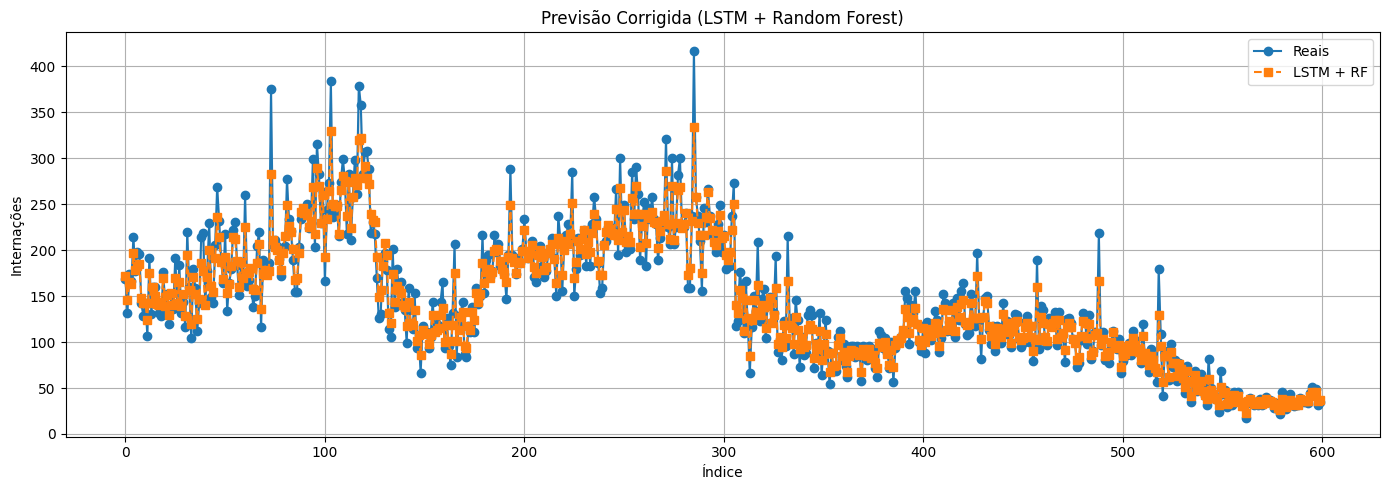

{'RMSE': 13.415370734890688,
 'MAE': 9.052162526611307,
 'MAPE (%)': 6.520434755992921}

In [35]:
rf_residual, y_pred_train_lstm_log = modelo_residual_rf(X_test_lstm, y_test_lstm, model_lstm)

avaliar_modelo_residual(model_lstm, rf_residual, X_test_lstm, y_test_lstm)